In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import seaborn as sns
import joblib
from nilearn import surface, datasets, plotting
from scipy import stats, ndimage
from statsmodels.stats.multitest import fdrcorrection
import pymcm

In [2]:
fname = '/RAID1/jupytertmp/mcm/data/data_group-tum.joblib'
group = joblib.load(fname)

In [5]:
resolution = 'fsaverage'
fsaverage = datasets.fetch_surf_fsaverage(mesh=resolution)

annot_lh = f'/RAID1/jupytertmp/mcm/data/external/schaefer/{resolution}/lh.Schaefer2018_400Parcels_7Networks_order.annot'
annot_rh = f'/RAID1/jupytertmp/mcm/data/external/schaefer/{resolution}/rh.Schaefer2018_400Parcels_7Networks_order.annot'
schaefer = pymcm.plotting.utils.load_annot(annot_lh, annot_rh)

annot_lh = f'/RAID1/jupytertmp/mcm/data/external/yeo/lh.Yeo2011_7Networks_N1000.annot'
yeo_cols = nib.freesurfer.read_annot(annot_lh)[1][1:,:-2] / 255
yeo_labels = ['Vis', 'SomMot', 'DAN', 'VAN', 'Limbic', 'Control', 'Default']

In [8]:
layers = np.loadtxt('/RAID1/jupytertmp/mcm/data/external/bigbrain/spaces/tpl-bigbrain/tpl-bigbrain_desc-profiles.txt')
layers = 1e5 / layers
nverts = layers.shape[1]

cytothickness = np.concatenate([
    np.sum([surface.load_surf_data(f'/RAID1/jupytertmp/mcm/data/external/bigbrain/layers/tpl-bigbrain_hemi-L_desc-layer{layer}.shape.gii') for layer in range(1,7)], axis=0),
    np.sum([surface.load_surf_data(f'/RAID1/jupytertmp/mcm/data/external/bigbrain/layers/tpl-bigbrain_hemi-R_desc-layer{layer}.shape.gii') for layer in range(1,7)], axis=0)
])

stain_avg = np.median(layers, axis=0) # this is meany.o

depth_percent = np.arange(1, 51)
D = np.repeat(depth_percent[:, np.newaxis], nverts, axis=1)
# skewness = stats.skew(layers, axis=0)
# kurtosis = stats.kurtosis(layers, axis=0)
means = np.average(D, weights=layers, axis=0) # meanx.o
vars = np.average((D - means)**2, weights=layers, axis=0)
stds = np.sqrt(vars) # std.o

m3s = np.average((D - means)**3, weights=layers, axis=0)
skews = m3s / vars**(3/2) # skew.o

sch_bb_left = surface.load_surf_data('/RAID1/jupytertmp/mcm/data/external/schaefer/bigbrain/tpl-bigbrain_lh.Schaefer2018_400Parcels_7Networks_order.label.gii')
sch_bb_right = surface.load_surf_data('/RAID1/jupytertmp/mcm/data/external/schaefer/bigbrain/tpl-bigbrain_rh.Schaefer2018_400Parcels_7Networks_order.label.gii')
schaefer_labels = np.concatenate([
    surface.load_surf_data('/RAID1/jupytertmp/mcm/data/external/schaefer/bigbrain/tpl-bigbrain_lh.Schaefer2018_400Parcels_7Networks_order.label.gii'),
    np.where(sch_bb_right > 0, sch_bb_right + 200, 0)
])

# deg_in = np.sqrt(group['ec_avg'].sum(axis=0))
# deg_out = np.sqrt(group['ec_avg'].sum(axis=1))
deg_in = group['directed'].sum(axis=0)
deg_out = group['directed'].sum(axis=1)
# deg_in = group.sub031['ec'].sum(axis=0)
# deg_out = group.sub031['ec'].sum(axis=1)
# deg_ratio = (deg_in + 1) / (deg_out + 1)
deg_ratio = deg_in - deg_out
deg = deg_in + deg_out

fc_deg = group['fc'].sum(axis=0)
sc_deg = group['sc_weight'].sum(axis=0)

cmrglc = np.mean([sub.pet['roiavgs'] for sub in group.iterraw()], axis=0)

In [9]:
def input_or_output(row, avg_skewness=0, avg_depth=np.median(means)):

    if row['avg_depth'] > avg_depth and row['skewness_z'] < avg_skewness:
        return 'output'
    elif row['avg_depth'] < avg_depth and row['skewness_z'] > avg_skewness:
        return 'input'
    else:
        return 'undefined'
    
def input_or_output_int(row, avg_skewness=0, avg_depth=np.median(means)):

    if row['avg_depth'] > avg_depth and row['skewness_z'] < avg_skewness:
        return 1
    elif row['avg_depth'] < avg_depth and row['skewness_z'] > avg_skewness:
        return 2
    else:
        return 0

In [10]:
df = pd.DataFrame(dict(
    roi=schaefer_labels,
    stain_avg=stain_avg,
    avg_depth=means,
    skewness=skews,
    skewness_z=stats.zscore(skews, nan_policy='omit'),
    thickness=cytothickness
))

df_clean = df.loc[(~df.skewness.isna()) & (df.thickness > 0), :]

df_rois = (
    df_clean.groupby('roi').agg(np.nanmedian)
    .assign(label=schaefer['left']['labels'] + schaefer['right']['labels'][1:])
)
df_rois['label'] = df_rois.label.apply(lambda x: x.decode('utf-8'))
df_rois['network'] = df_rois.label.apply(lambda x: x.split('_')[2])
df_rois = df_rois.iloc[1:, :]

df_rois = df_rois.join(
    pd.DataFrame(dict(
        cmrglc=cmrglc,
        fc_deg=fc_deg, 
        sc_deg=sc_deg, 
        deg=deg, 
        deg_in=deg_in, 
        deg_out=deg_out, 
        deg_ratio=deg_ratio
        ), index=group['roi_template']),
    how='left'
)

df_rois['dir'] = df_rois.apply(input_or_output, axis=1)
df_rois['dir_num'] = df_rois.apply(input_or_output_int, axis=1)

/tmp/ipykernel_3113576/45244085.py:13: FutureWarning: The provided callable <function nanmedian at 0x7f099021f4c0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df_clean.groupby('roi').agg(np.nanmedian)


---

In [11]:
depth_percent = np.linspace(1, 100, 50)
freq = layers[:, 1000]

# mean = np.sum(depth_percent * freq) / np.sum(freq)
# std = np.sqrt(np.sum(freq * (depth_percent - mean)**2) / (np.sum(freq) - 1))

mean = np.average(depth_percent, weights=freq)
var = np.average( (depth_percent - mean)**2, weights=freq )
std = np.sqrt(var)

m3 = np.average( (depth_percent - mean)**3, weights=freq )
skew = m3 / var**(3/2)

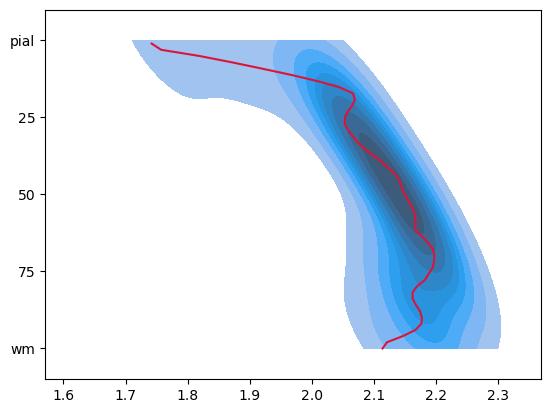

In [12]:
ax = sns.kdeplot(x=freq, y=depth_percent, fill=True, clip=(0,100))
ax.invert_yaxis()
# ax.set(ylim=(110, -10))
ax.set(yticks=np.linspace(0, 100, 5), ylim=(110, -10), yticklabels=['pial', 25, 50, 75, 'wm']);

ax.plot(freq, depth_percent, color='crimson')

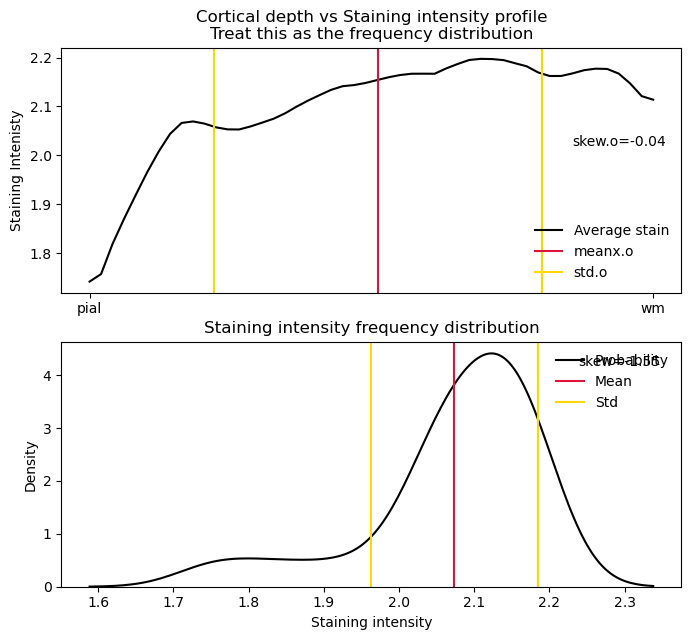

In [13]:
avg = np.mean(layers, axis=1)

fig, axs = plt.subplots(2,1, figsize=(8,7))
axs[0].plot(depth_percent, freq, label='Average stain', color='k')

axs[0].axvline(mean, color='crimson', label='meanx.o')
axs[0].axvline(mean - std, color='gold', label='std.o')
axs[0].axvline(mean + std, color='gold')
# axtwin = axs[0].twinx()
# axtwin.plot(range(50), np.gradient(avg), label='Derivative', color='crimson')
# axtwin.legend()

sns.kdeplot(avg, ax=axs[1],color='k', label='Probability')
axs[1].axvline(np.mean(avg), color='crimson', label='Mean')
axs[1].axvline(np.mean(avg) - np.std(avg), color='gold', label='Std')
axs[1].axvline(np.mean(avg) + np.std(avg), color='gold')

axs[0].set(xticks=[depth_percent.min(), depth_percent.max()], xticklabels=['pial', 'wm'], ylabel='Staining Intenisty', title='Cortical depth vs Staining intensity profile\nTreat this as the frequency distribution')
axs[1].set(xlabel='Staining intensity', title='Staining intensity frequency distribution')

axs[0].text(0.9, 0.6, f'skew.o={skew:.2f}', transform=axs[0].transAxes, horizontalalignment='center')
axs[1].text(0.9, 0.9, f'skew={stats.skew(avg):.2f}', transform=axs[1].transAxes, horizontalalignment='center')

for ax in axs:
    ax.legend(frameon=False)

---

# Fsaverage vs Bigbrain thickness

In [27]:
thickness = np.concatenate([
    surface.load_surf_data(fsaverage['thick_left']),
    surface.load_surf_data(fsaverage['thick_right'])
])

[Text(0.5, 0, 'big brain thickness'), Text(0, 0.5, 'fsaverage thickness')]

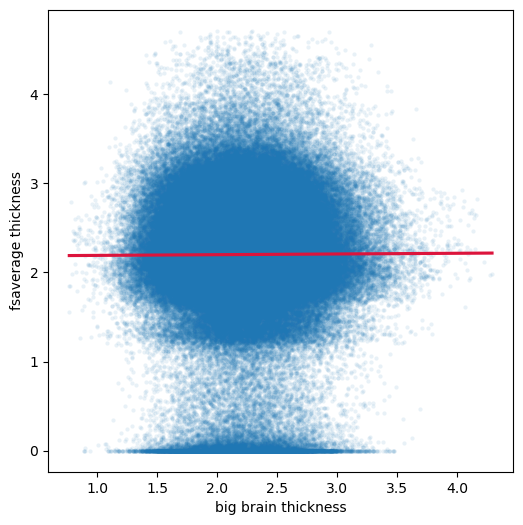

In [28]:
fig, ax = plt.subplots(figsize=(6,6))
sns.regplot(x=cytothickness[cytothickness>0], y=thickness[cytothickness>0], 
            marker='.', scatter_kws={'alpha': 0.1, 'linewidths': 0}, line_kws={'color': 'crimson'}, ax=ax)
ax.set(xlabel='big brain thickness', ylabel='fsaverage thickness')

In [29]:
plotting.plot_surf_stat_map(
    surf_mesh=fsaverage['pial_left'], 
    stat_map=np.sum([surface.load_surf_data(f'/RAID1/jupytertmp/mcm/bigbrain/layers/tpl-fsaverage_hemi-L_desc-layer{layer}.shape.gii') for layer in range(1,7)], axis=0),
    hemi='left',
    bg_map=fsaverage['sulc_left'], bg_on_data=True, darkness=.5
);

ValueError: No files matching path: /RAID1/jupytertmp/mcm/bigbrain/layers/tpl-fsaverage_hemi-L_desc-layer1.shape.gii

In [ ]:
display = plotting.plot_surf_roi(
    surf_mesh='/RAID1/jupytertmp/mcm/bigbrain/spaces/tpl-bigbrain/tpl-bigbrain_hemi-R_desc-pial.surf.gii',
    roi_map='/RAID1/jupytertmp/mcm/schaefer/bigbrain/tpl-bigbrain_rh.Schaefer2018_400Parcels_7Networks_order.label.gii',
    bg_map='/RAID1/jupytertmp/mcm/bigbrain/spaces/tpl-bigbrain/tpl-bigbrain_hemi-R.sulc',
    bg_on_data=True,
    hemi='right',
    view='medial',
    darkness=0.5,
    cmap=schaefer['right']['cmap']
)

Text(0.75, 0.1, 'dense superficial layers')

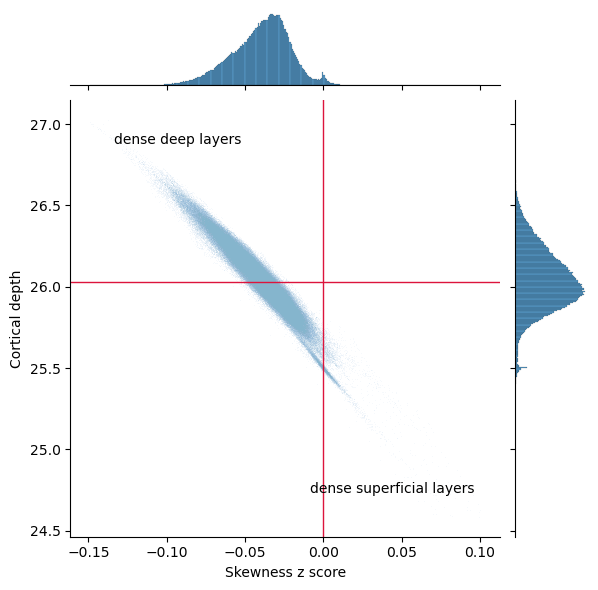

In [30]:
g = sns.jointplot(data=df, x='skewness', y='avg_depth', kind='scatter',
            joint_kws={'marker': '.', 'linewidths': 0, 'alpha': 0.1, 's': 1})
ax = g.ax_joint

ax.set(xlabel='Skewness z score', ylabel='Cortical depth')
ax.axhline(np.median(means), c='crimson', linewidth=1)
ax.axvline(0, c='crimson', linewidth=1)

ax.text(0.25, 0.9, 'dense deep layers', horizontalalignment='center', transform=ax.transAxes)
ax.text(0.75, 0.1, 'dense superficial layers', horizontalalignment='center', transform=ax.transAxes)

In [32]:
df_rois

,stain_avg,avg_depth,skewness,skewness_z,thickness,label,network,cmrglc,fc_deg,sc_deg,deg,deg_in,deg_out,deg_ratio,dir,dir_num
roi,,,,,,,,,,,,,,,,
1,2.168110,26.123499,-0.049140,-0.486458,2.275652,7Networks_LH_Vis_1,Vis,27.132763,49.172693,3.653743,1.136745,1.071917,0.064828,1.007089,output,1
2,2.102343,26.078748,-0.046243,-0.334100,2.220598,7Networks_LH_Vis_2,Vis,25.391474,53.950521,6.704666,1.523976,0.847551,0.676425,0.171125,output,1
3,2.274123,26.347548,-0.072906,-1.736034,2.347733,7Networks_LH_Vis_3,Vis,28.192673,67.581109,4.830054,1.502442,0.889493,0.612950,0.276543,output,1
4,2.158826,26.223951,-0.059420,-1.026930,2.116314,7Networks_LH_Vis_4,Vis,29.560043,73.057776,10.982501,1.877591,0.942619,0.934972,0.007647,output,1
5,2.302025,26.371764,-0.079317,-2.073078,2.214204,7Networks_LH_Vis_5,Vis,30.844528,73.070331,12.473396,1.892406,1.170478,0.721929,0.448549,output,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,2.229100,26.193114,-0.055198,-0.804969,2.373076,7Networks_RH_Default_pCunPCC_5,Default,39.294781,49.015443,3.921822,1.617698,1.556758,0.060940,1.495818,output,1
397,2.142215,25.960358,-0.030301,0.504049,2.306814,7Networks_RH_Default_pCunPCC_6,Default,36.859550,63.136201,6.869511,3.265254,2.358923,0.906331,1.452592,input,2
398,2.118376,25.967554,-0.031460,0.443161,2.173629,7Networks_RH_Default_pCunPCC_7,Default,35.195530,60.968029,6.893596,2.726480,2.236807,0.489673,1.747134,input,2


In [38]:
df_grouped = df_rois.groupby('network', sort=False).agg('median', numeric_only=True).reset_index()
df_grouped['dir'] = df_grouped.apply(input_or_output, axis=1)

/tmp/ipykernel_3113576/3074139178.py:2: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.scatterplot(data=df_rois, x='skewness_z', y='avg_depth', hue='network', palette=yeo_cols, alpha=0.8, linewidths=None)
/tmp/ipykernel_3113576/3074139178.py:4: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(data=df_grouped, x='skewness_z', y='avg_depth', hue='network', marker='X', s=100, palette=yeo_cols, ax=ax, legend=False, linewidths=None)


Text(0.8, 0.1, 'dense superficial\ni.e. "inputs"')

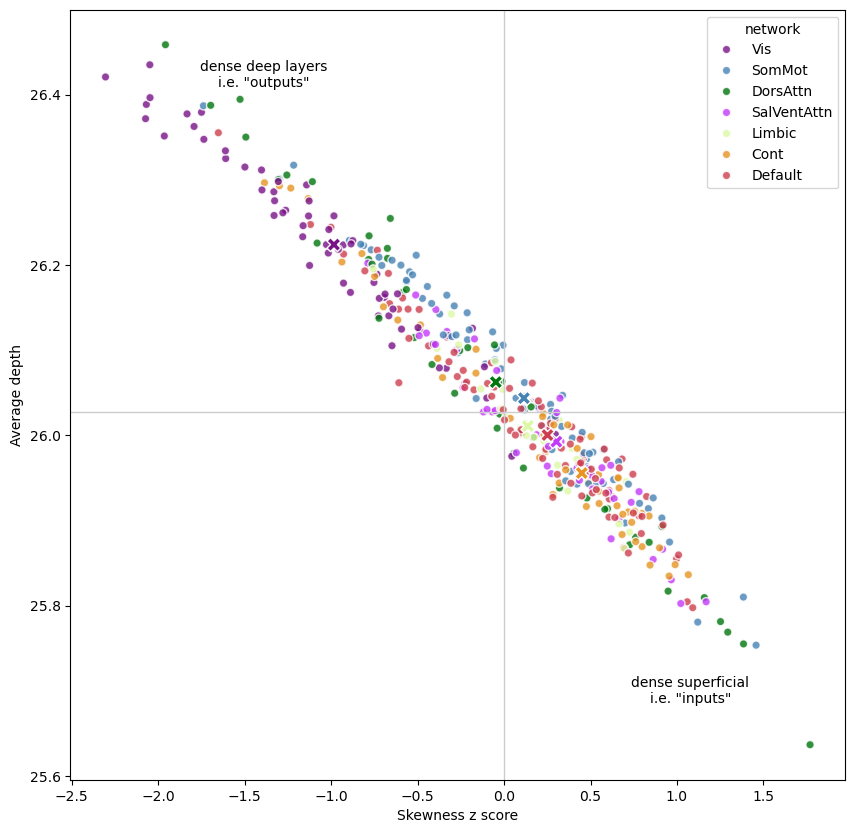

In [39]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.scatterplot(data=df_rois, x='skewness_z', y='avg_depth', hue='network', palette=yeo_cols, alpha=0.8, linewidths=None)

sns.scatterplot(data=df_grouped, x='skewness_z', y='avg_depth', hue='network', marker='X', s=100, palette=yeo_cols, ax=ax, legend=False, linewidths=None)

ax.set(xlabel='Skewness z score', ylabel='Average depth')
ax.axhline(np.median(means), c='0.8', linewidth=1)
ax.axvline(0, c='0.8', linewidth=1)

ax.text(0.25, 0.9, 'dense deep layers\ni.e. "outputs"', size=10, horizontalalignment='center', transform=ax.transAxes)
ax.text(0.8, 0.1, 'dense superficial\ni.e. "inputs"', size=10, horizontalalignment='center', transform=ax.transAxes)

/tmp/ipykernel_3113576/4177382869.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), size=15)


[Text(0, 25.400000000000002, '25.4'),
 Text(0, 25.6, '25.6'),
 Text(0, 25.8, '25.8'),
 Text(0, 26.000000000000004, '26.0'),
 Text(0, 26.200000000000003, '26.2'),
 Text(0, 26.400000000000002, '26.4'),
 Text(0, 26.6, '26.6')]

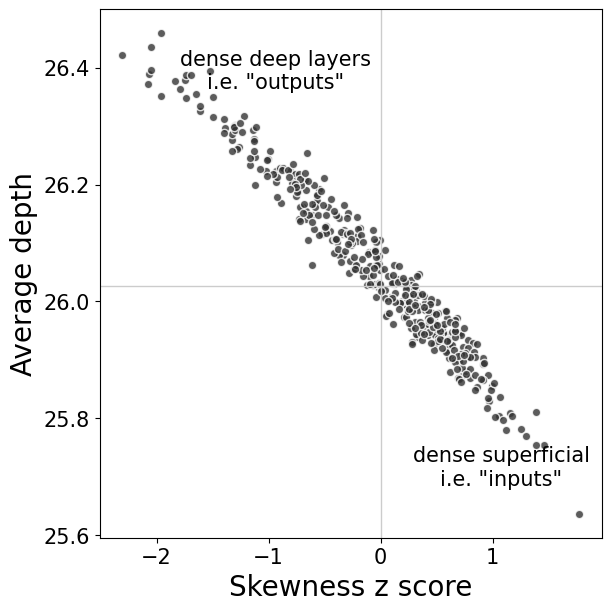

In [40]:
fig, ax = plt.subplots(figsize=(6,6), constrained_layout=True)
ax = sns.scatterplot(data=df_rois, x='skewness_z', y='avg_depth', alpha=0.8, linewidths=None, color='0.2')

ax.axvline(0, c='0.8', linewidth=1)
ax.axhline(np.median(means), c='0.8', linewidth=1)

ax.text(0.35, 0.85, 'dense deep layers\ni.e. "outputs"', size=15, horizontalalignment='center', transform=ax.transAxes)
ax.text(0.8, 0.1, 'dense superficial\ni.e. "inputs"', size=15, horizontalalignment='center', transform=ax.transAxes)

ax.set_xlabel('Skewness z score', fontsize=20)
ax.set_ylabel('Average depth', fontsize=20)

ax.set_xticks([-2, -1, 0, 1])
ax.set_xticklabels(ax.get_xticklabels(), size=15)
ax.set_yticklabels(ax.get_yticklabels(), size=15)

# fig.savefig('/home/tumnic/rbelenya/mcm/notebooks/paper/skewness-depth.png',
#             dpi=300,
#             transparent=True,
#             bbox_inches='tight'
#             )

<Axes: xlabel='network', ylabel='deg_ratio'>

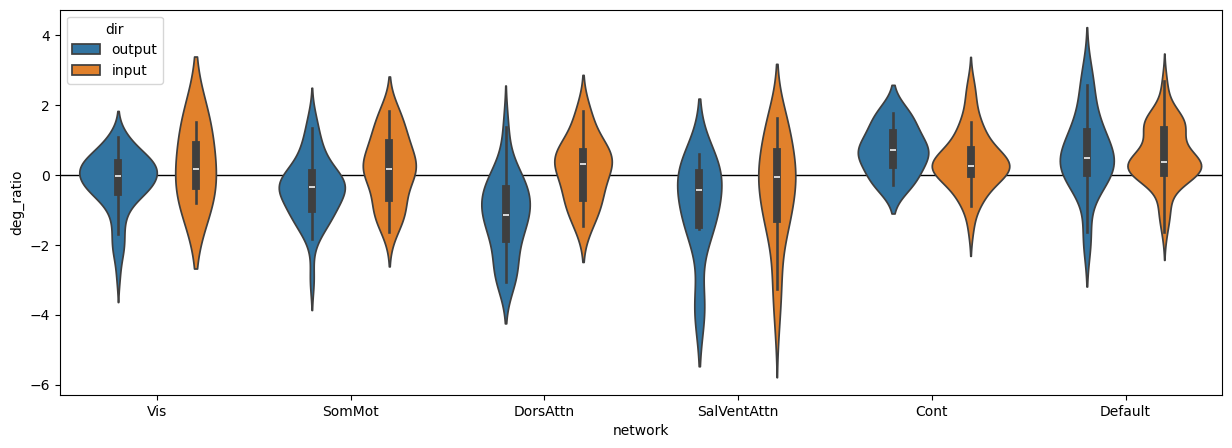

In [41]:
fig, ax = plt.subplots(figsize=(15,5))
ax.axhline(0, linewidth=1, color='k', zorder=0)

subset = df_rois.loc[(df_rois.dir != 'undefined') & (df_rois.network != 'Limbic'), :]
sns.violinplot(data=subset, x='network', y='deg_ratio', hue='dir', ax=ax)


/tmp/ipykernel_3113576/1248682885.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=subset, x='dir', y='deg_ratio', capsize=0.1, errwidth=1, ax=ax)
/tmp/ipykernel_3113576/1248682885.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='In/Out\ndegree ratio', xlabel='Layer profile', xticklabels=['Dense deep', 'Dense superficial'])


TtestResult(statistic=4.121648305548276, pvalue=4.734522705718428e-05, df=338.87390872997236)

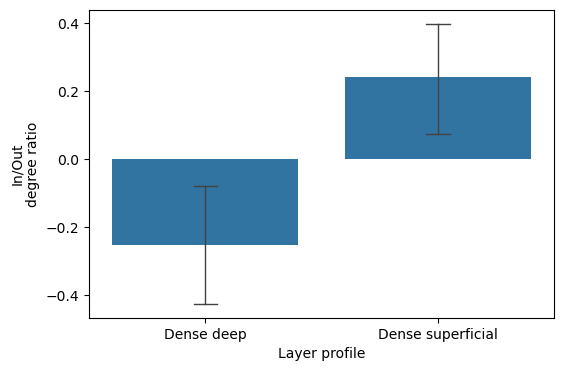

In [42]:
fig,ax = plt.subplots(1,1, figsize=(6,4))

sns.barplot(data=subset, x='dir', y='deg_ratio', capsize=0.1, errwidth=1, ax=ax)
ax.set(ylabel='In/Out\ndegree ratio', xlabel='Layer profile', xticklabels=['Dense deep', 'Dense superficial'])

# fig.savefig('/home/tumnic/rbelenya/mcm/notebooks/paper/degree-stain.png',
#             dpi=300,
#             transparent=True,
#             bbox_inches='tight'
#             )

deg_in = subset.loc[subset.dir == 'input', 'deg_ratio']
deg_in = deg_in[~np.isnan(deg_in)]

deg_out = subset.loc[subset.dir == 'output', 'deg_ratio']
deg_out = deg_out[~np.isnan(deg_out)]

stats.ttest_ind(deg_in, deg_out, equal_var=False)

In [43]:
atlas = np.concatenate([schaefer['left']['atlas'], np.where(schaefer['right']['atlas'] > 0, schaefer['right']['atlas'] + 200, 0)])
tex = np.zeros(atlas.shape)

for idx, label in enumerate(np.unique(atlas)):
    if label == 0:
        continue
    tex[atlas == label] = df_rois.loc[idx, 'dir_num']

tex_left, tex_right = np.split(tex, 2)

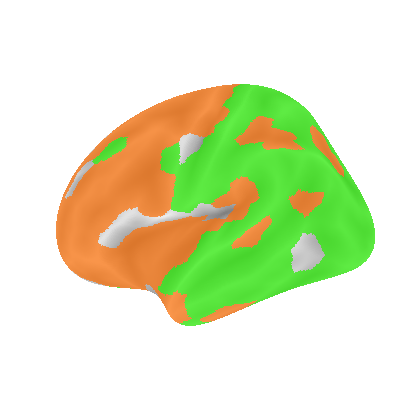

In [44]:
plotting.plot_surf_roi(
    surf_mesh=fsaverage['infl_left'],
    roi_map=tex_left,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True,
    hemi='left',
    view='lateral',
    darkness=0.5
);

In [45]:
ps = []
ts = []

nets = ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Cont', 'Default']
for net in nets:
    subset = df_rois.loc[df_rois.network == net, :]
    x1 = subset.loc[subset.dir == 'input', 'deg_ratio']
    x2 = subset.loc[subset.dir == 'output', 'deg_ratio']

    t, p = stats.ttest_ind(x1[~np.isnan(x1)], x2[~np.isnan(x2)], equal_var=False)
    ts.append(t)
    ps.append(p)

ps_adj = fdrcorrection(ps)

list(zip(nets, ps))

[('Vis', 0.5399960884094959),
 ('SomMot', 0.015614483357155224),
 ('DorsAttn', 0.00019373198766323117),
 ('SalVentAttn', 0.3069885626316621),
 ('Cont', 0.21578431055325495),
 ('Default', 0.828927674081244)]

/RAID1/miniconda3/envs/roman/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  func(x=vector, **plot_kwargs)
/RAID1/miniconda3/envs/roman/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  func(x=vector, **plot_kwargs)
/RAID1/miniconda3/envs/roman/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  func(x=vector, **plot_kwargs)
/RAID1/miniconda3/envs/roman/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  func(x=vector,

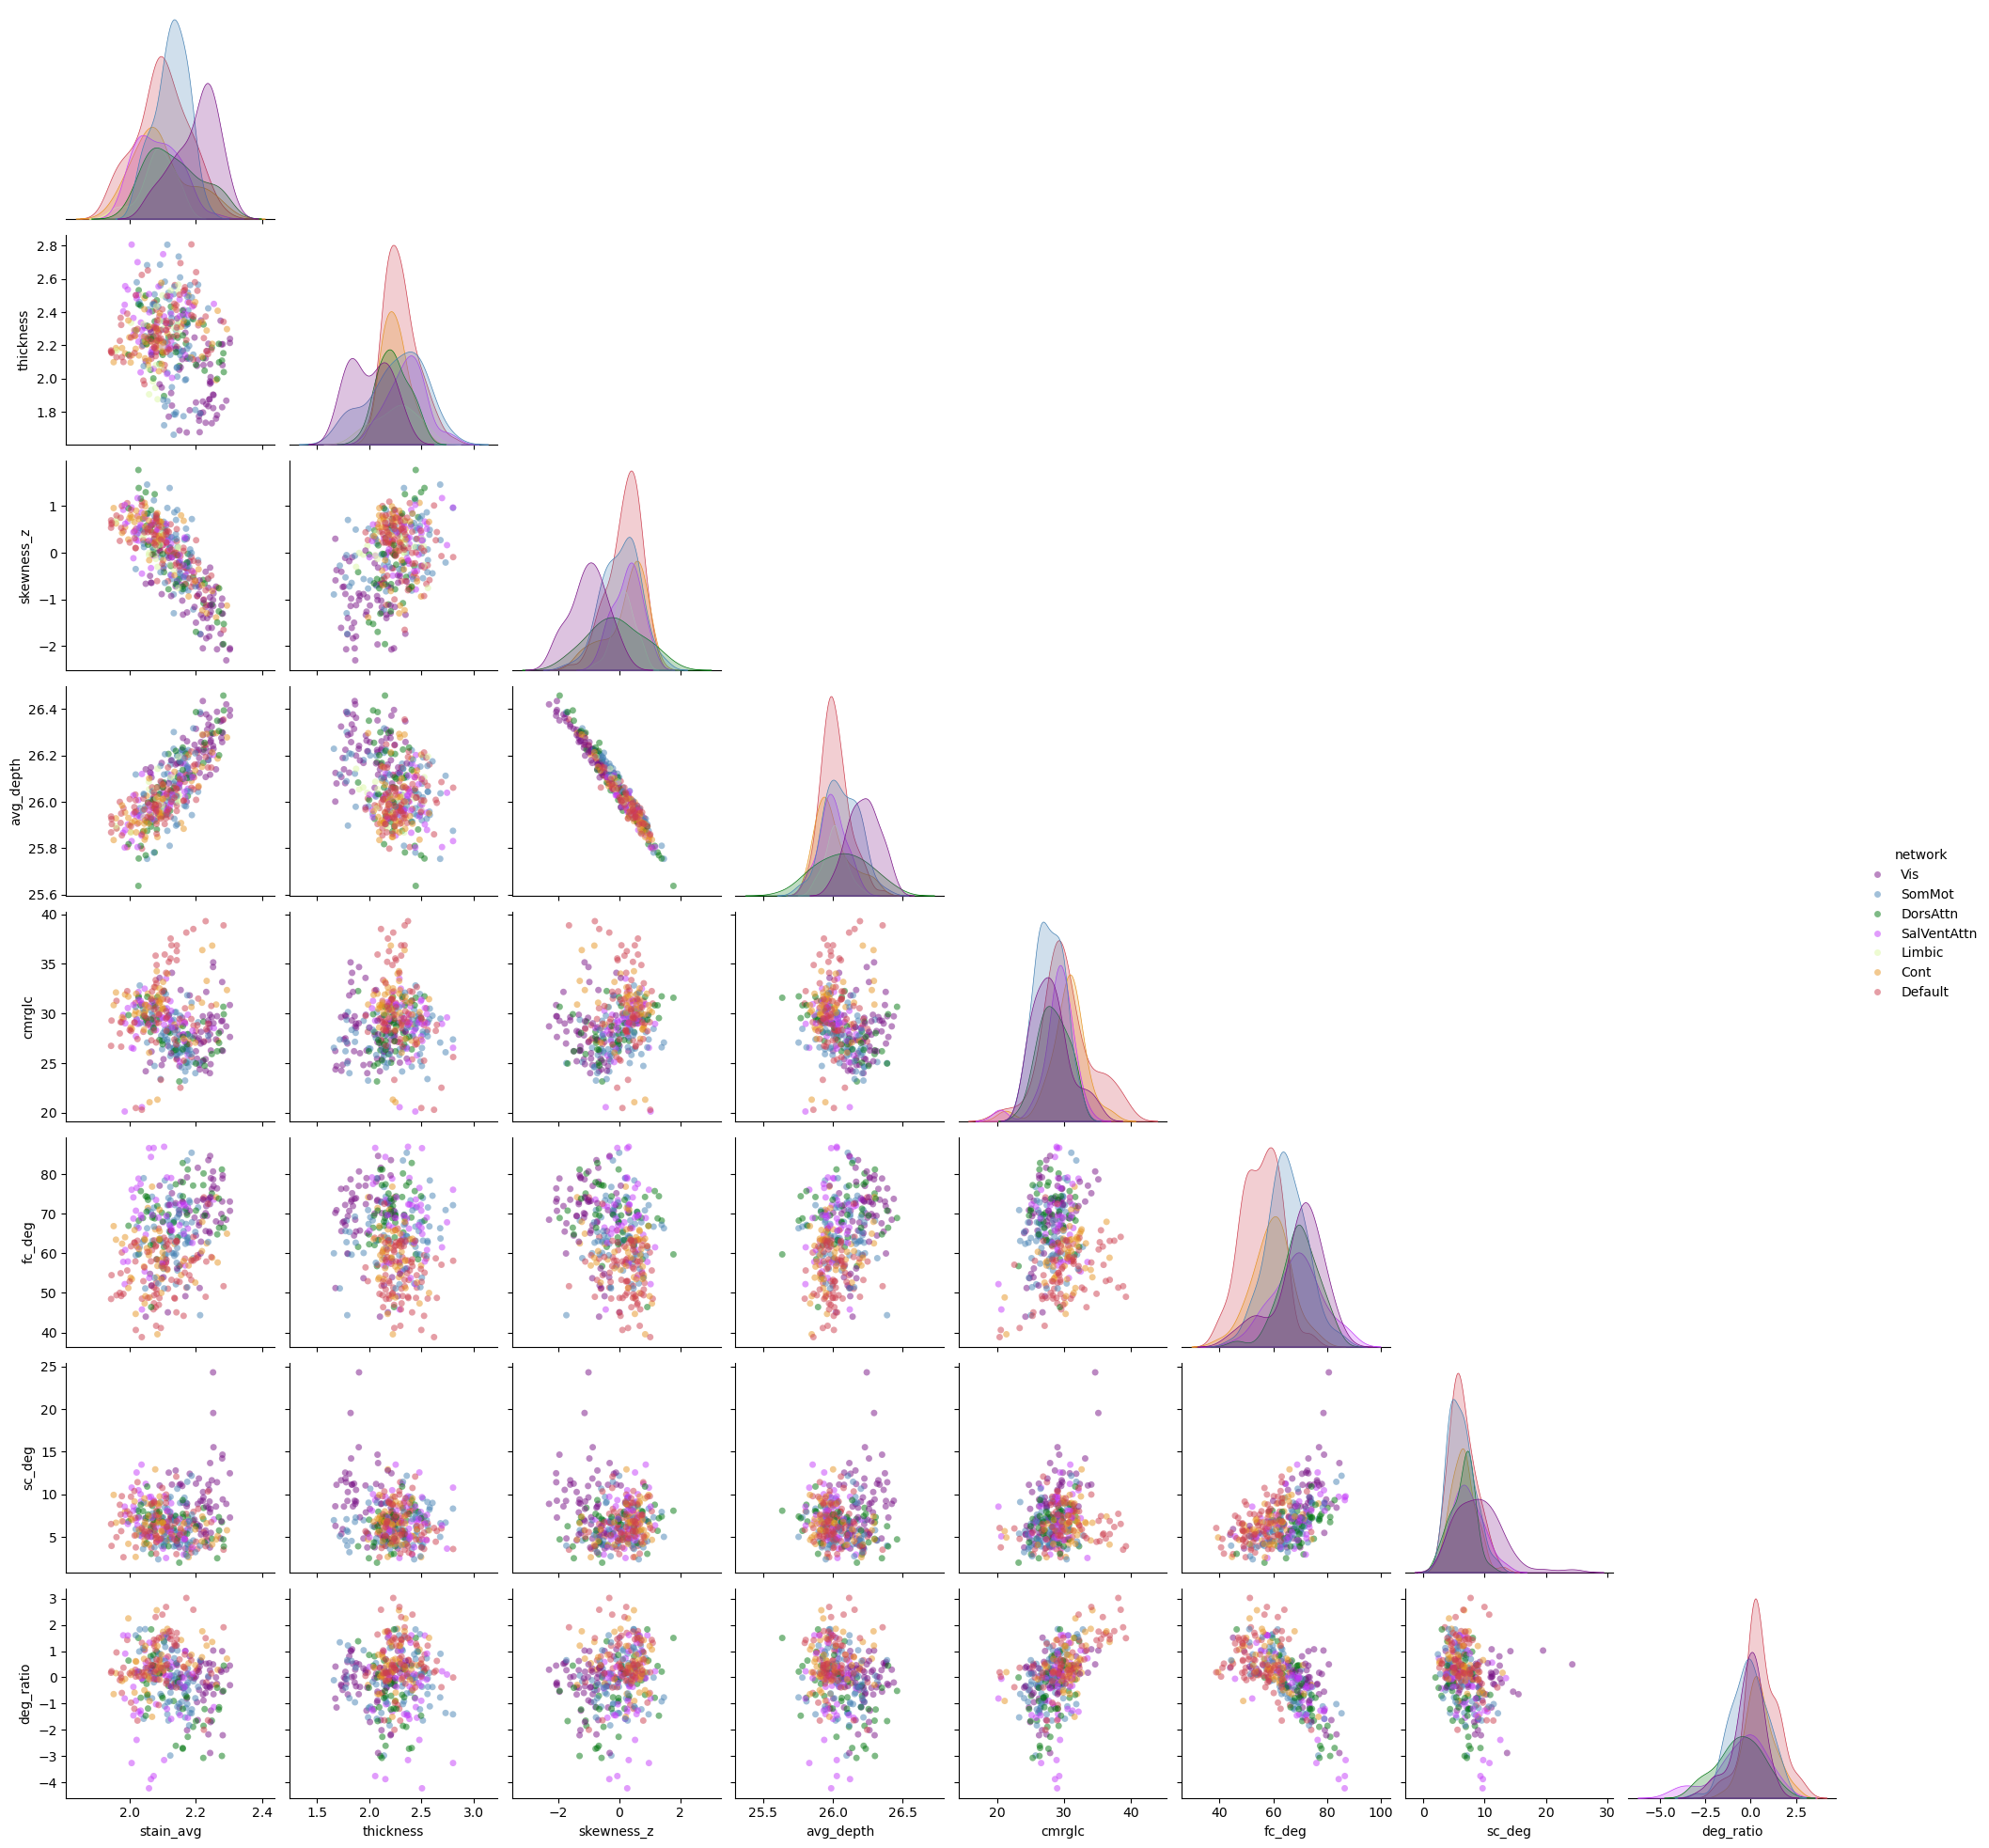

In [46]:
pairplot = sns.pairplot(df_rois[['stain_avg', 'thickness', 'skewness_z', 'avg_depth', 'cmrglc', 'fc_deg', 'sc_deg', 'deg_ratio', 'network']], hue='network', kind='scatter',
            palette=yeo_cols, 
            plot_kws={'marker': '.', 'linewidth': 0, 'alpha': 0.5, 's': 100},
            diag_kws={'linewidth': 0.5}, 
            corner=True)

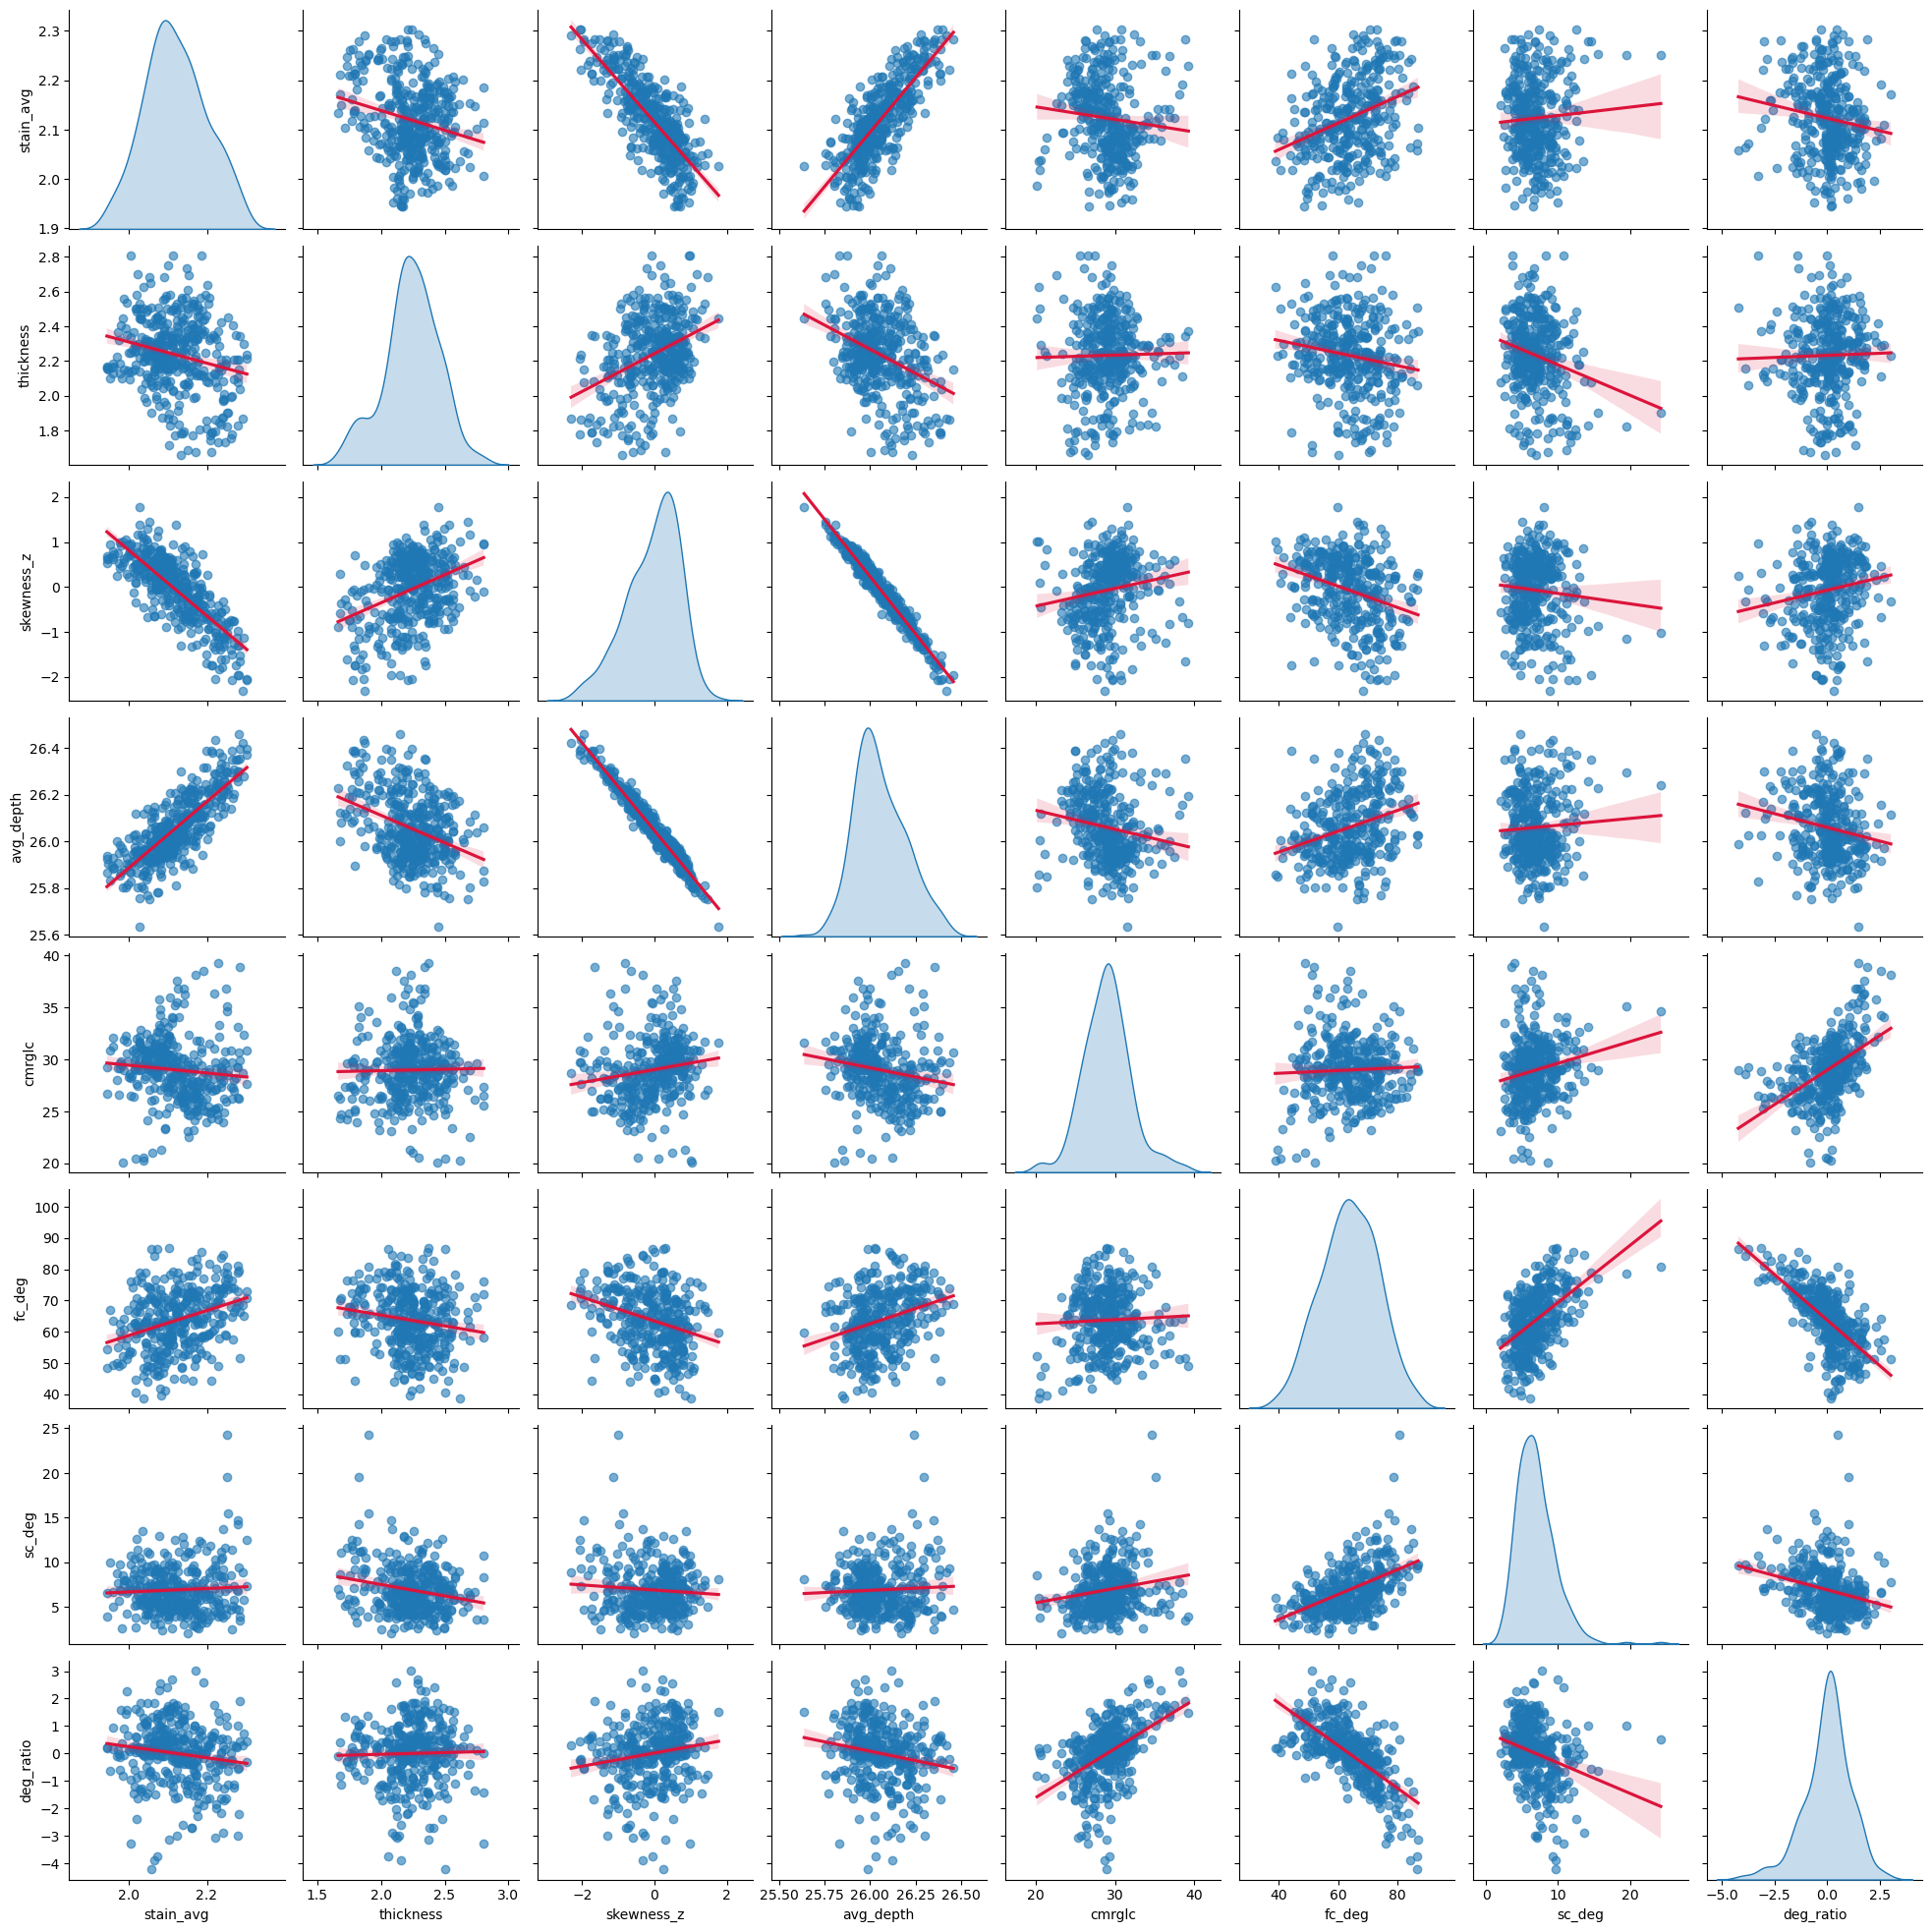

In [47]:
pairplot = sns.pairplot(df_rois[['stain_avg', 'thickness', 'skewness_z', 'avg_depth', 'cmrglc', 'fc_deg', 'sc_deg', 'deg_ratio', 'network']], kind='reg', 
            plot_kws={'line_kws': {'color': 'crimson'}, 'scatter_kws': {'marker': '.', 'alpha': 0.6}}, diag_kind='kde',
            )

---

In [15]:
avg_depth = df.avg_depth.median()
dense_deep_rois = df_rois.loc[(df_rois.avg_depth > avg_depth) & (-1.5 < df_rois.skewness_z) & (df_rois.skewness_z < -1.4)]
dense_superficial_rois = df_rois.loc[(df_rois.avg_depth < avg_depth) & (1.4 < df_rois.skewness_z)]

idcs, = np.where(schaefer_labels == 19)
dense_deep_roi_profile = layers[:, idcs]
dense_deep_roi_avg_profile = dense_deep_roi_profile.mean(axis=1)

depth = np.arange(1, 51)
# D = np.repeat(depth_percent[:, np.newaxis], nverts, axis=1)
# # skewness = stats.skew(layers, axis=0)
# # kurtosis = stats.kurtosis(layers, axis=0)
# means = np.average(D, weights=layers, axis=0) # meanx.o
# vars = np.average((D - means)**2, weights=layers, axis=0)
# stds = np.sqrt(vars) # std.o

# m3s = np.average((D - means)**3, weights=layers, axis=0)
# skews = m3s / vars**(3/2) # skew.o

dense_deep_roi_avg_profile_depth = np.average(depth, weights=dense_deep_roi_avg_profile, axis=0)
dense_deep_roi_avg_profile_var = np.average((depth - dense_deep_roi_avg_profile_depth)**2, weights=dense_deep_roi_avg_profile, axis=0)
dense_deep_roi_avg_profile_std = np.sqrt(dense_deep_roi_avg_profile_var)
m3 = np.average((depth - dense_deep_roi_avg_profile_depth)**3, weights=dense_deep_roi_avg_profile, axis=0)
dense_deep_roi_avg_profile_skew = m3 / dense_deep_roi_avg_profile_var**(3/2)

In [ ]:
plt.rc('font', size=15)          # controls default text sizes
plt.rc('axes', titlesize=20)     # fontsize of the axes title
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=15)    # fontsize of the tick labels
plt.rc('ytick', labelsize=15)    # fontsize of the tick labels
plt.rc('legend', fontsize=15)    # legend fontsize
plt.rc('figure', titlesize=20)  # fontsize of the figure title

Text(0.8, 0.8, 'skew = -0.07')

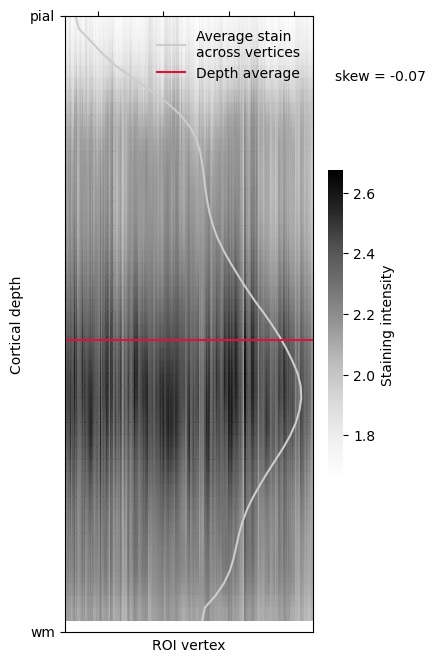

In [56]:
fig, ax = plt.subplots(figsize=(4,8))
ax1 = ax.twiny()

sns.heatmap(dense_deep_roi_profile, ax=ax, cmap='Greys', cbar_kws={'shrink': 0.5, 'label': 'Staining intensity'}, shading='gouraud')
ax1.plot(dense_deep_roi_profile.mean(axis=1), np.arange(50), color='0.8', label='Average stain\nacross vertices')
ax1.axhline(dense_deep_roi_avg_profile_depth, color='crimson', label='Depth average')
# ax1.axhline(dense_deep_roi_avg_depth, color='white')

ax1.set(xticklabels=[])
ax.set(xlabel='ROI vertex', ylabel='Cortical depth', yticks=[0, 50])
ax.set_yticklabels(['pial', 'wm'], rotation=0)
ax.set_xticks([])

ax1.legend(frameon=False)

fig.text(0.8,0.8, f'skew = {dense_deep_roi_avg_profile_skew:.2f}')

# fig.savefig('/home/tumnic/rbelenya/mcm/notebooks/paper/staining-intensity.png',
#             dpi=300,
#             transparent=True,
#             bbox_inches='tight'
#             )

In [17]:
pos_skew_idcs = df.loc[(df.skewness_z > 1.4999) & (df.skewness_z < 1.5) & (df.thickness < df.thickness.median())].index.to_numpy()
neg_skew_idcs = df.loc[(df.skewness_z < -1.4999) & (df.skewness_z > -1.5) & (df.thickness > df.thickness.median())].index.to_numpy()

Text(0.5, 1.0, 'Thick + Negative skew: dense supragranular layers')

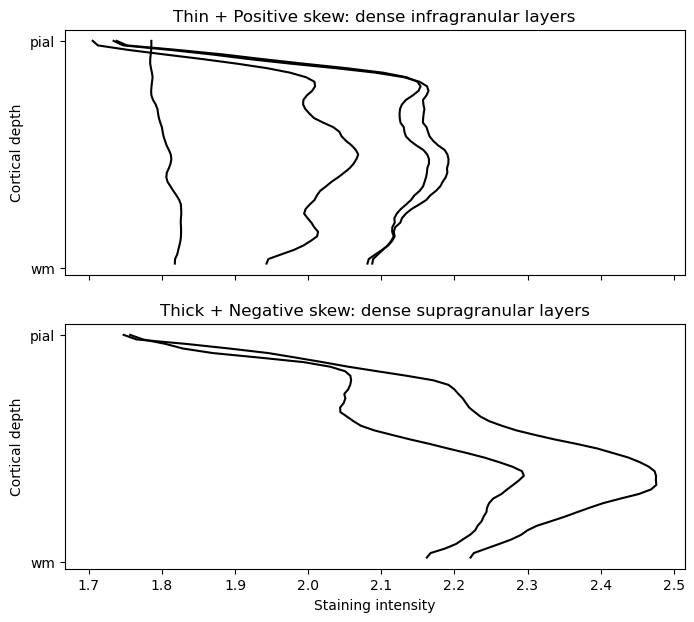

In [18]:
fig, axs = plt.subplots(2,1, figsize=(8,7), sharey=True, sharex=True)
axs[0].plot(layers[:, pos_skew_idcs], np.arange(50), color='k')
axs[1].plot(layers[:, neg_skew_idcs], np.arange(50), color='k')

axs[0].invert_yaxis()
for ax in axs:
    ax.set(yticks=[0,50], yticklabels=('pial', 'wm'), ylabel='Cortical depth')

axs[1].set_xlabel('Staining intensity')
axs[0].set_title('Thin + Positive skew: dense infragranular layers')
axs[1].set_title('Thick + Negative skew: dense supragranular layers')        

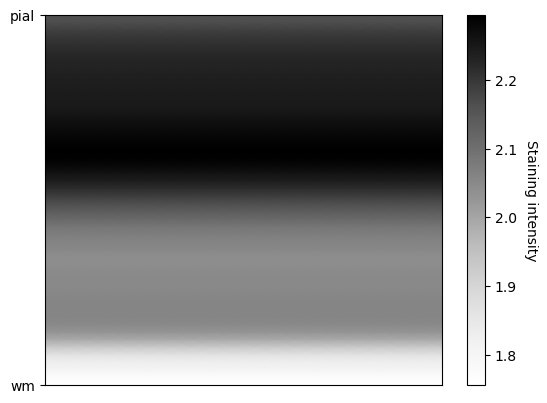

In [21]:
l = layers[:, neg_skew_idcs[0]]

ax = plt.pcolormesh(np.repeat(l, 20, axis=0).reshape(50,20), cmap='Greys', shading='gouraud')
cbar = plt.colorbar()
cbar.ax.get_yaxis().labelpad = 15
cbar.ax.set_ylabel('Staining intensity', rotation=270)

ax.axes.set(xticklabels=[], xticks=[], yticks=[0,49], yticklabels=['wm', 'pial']);

## ROIS

In [23]:
deg_in = group['directed'].sum(axis=0)
deg_out = group['directed'].sum(axis=1)
# deg_in = group.sub031['ec'].sum(axis=0)
# deg_out = group.sub031['ec'].sum(axis=1)
deg_ratio = stats.zscore(deg_in) / stats.zscore(deg_out)

In [24]:
from sklearn import preprocessing

deg_ratio_scaled = preprocessing.MinMaxScaler(feature_range=(-1, 1)).fit_transform(deg_ratio[:, np.newaxis])
deg_ratio_scaled = preprocessing.PowerTransformer(method='yeo-johnson').fit_transform(deg_ratio[:, np.newaxis])

In [25]:
staining_skew_subet = staining_skew[group['roi_template']]

NameError: name 'staining_skew' is not defined

In [26]:
sns.kdeplot(staining_skew_subet)

NameError: name 'staining_skew_subet' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
cmrglc_avg = np.mean([sub['cmrglc_adj'] for sub in group.iterraw()], axis=0)
sns.regplot(x=staining_skew_subet, y=cmrglc_avg, robust=True, ax=ax)
ax.set(xlabel='Staining intensity skew', ylabel='Cmrglc adj')

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
sns.kdeplot(deg_in, ax=ax)
sns.kdeplot(deg_out, ax=ax)

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
sns.kdeplot(deg_ratio, ax=ax)

In [ ]:
df = pd.DataFrame(dict(stain=staining_skew_subet, aff=deg_in, eff=deg_out)).melt(id_vars='stain', var_name='direction')

In [ ]:
sns.lmplot(data=df, x='stain', y='value', col='direction', robust=True)

In [ ]:
std = np.std(deg_ratio)
outliers = (deg_ratio > 3 * std) | (deg_ratio < -3 * std)

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
sns.regplot(x=staining_skew_subet[~outliers], y=deg_ratio[~outliers], ax=ax, scatter_kws={'linewidths': 0, 'alpha': 0.7}, line_kws={'color': 'r'})

ax.set_ylim([-10, 10])

In [ ]:
print(stats.pearsonr(staining_skew_subet, deg_ratio))
print(stats.spearmanr(staining_skew_subet, deg_ratio))

In [ ]:
layers = np.loadtxt('https://raw.githubusercontent.com/NeuroenergeticsLab/energetic_costs/main/data/external/BigBrainWarp/tpl-fs_LR_den-32k_desc-profiles.txt', delimiter=',')
sns.heatmap(layers, cmap='Greys')

In [ ]:
ax = sns.kdeplot(layers[:, 100])
ax.axvline(np.median(layers[:, 100]))

In [ ]:
sns.kdeplot(np.median(layers, axis=0))

In [ ]:
sns.kdeplot(np.median(layers, axis=1))

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(np.median(layers, axis=1), np.arange(1,51))
ax.invert_yaxis()

ax.set(yticks=[0,50], yticklabels=('pial', 'wm'), ylabel='Cortical depth', xlabel='Stain intensity')